<a href="https://colab.research.google.com/github/onuda22/skripsi-apple-diseases/blob/main/AB5_0%2C25_256_RMSprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Import Library

In [ ]:
import os
import shutil
import random
import cv2
import time

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from sklearn.metrics import confusion_matrix

#Transformasi Data

In [ ]:
path_dir = '/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_B'

In [ ]:
names = []
nums = []
data = {'Nama Kelas':[], 'Jumlah Sample':[]}

for i in os.listdir(path_dir+'/train'):
  nums.append(len(os.listdir(path_dir+'/train/'+i)))
  names.append(i)

data['Nama Kelas']+=names
data['Jumlah Sample']+=nums

df = pd.DataFrame(data)
df

,Nama Kelas,Jumlah Sample
0,Healthy,192
1,Apple_Rust,192
2,Apple_Scab,192


<Axes: xlabel='Nama Kelas', ylabel='Jumlah Sample'>

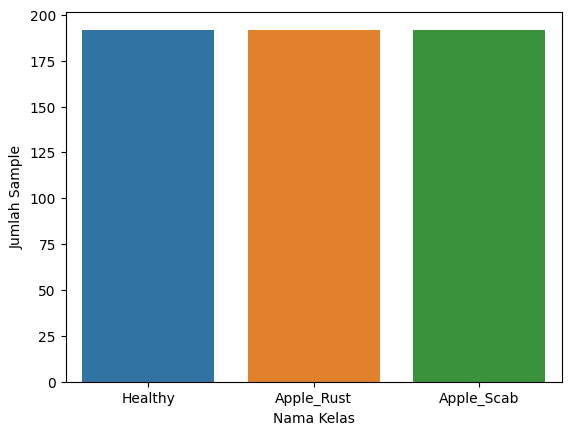

In [ ]:
sns.barplot(x=df['Nama Kelas'],y=df['Jumlah Sample'])

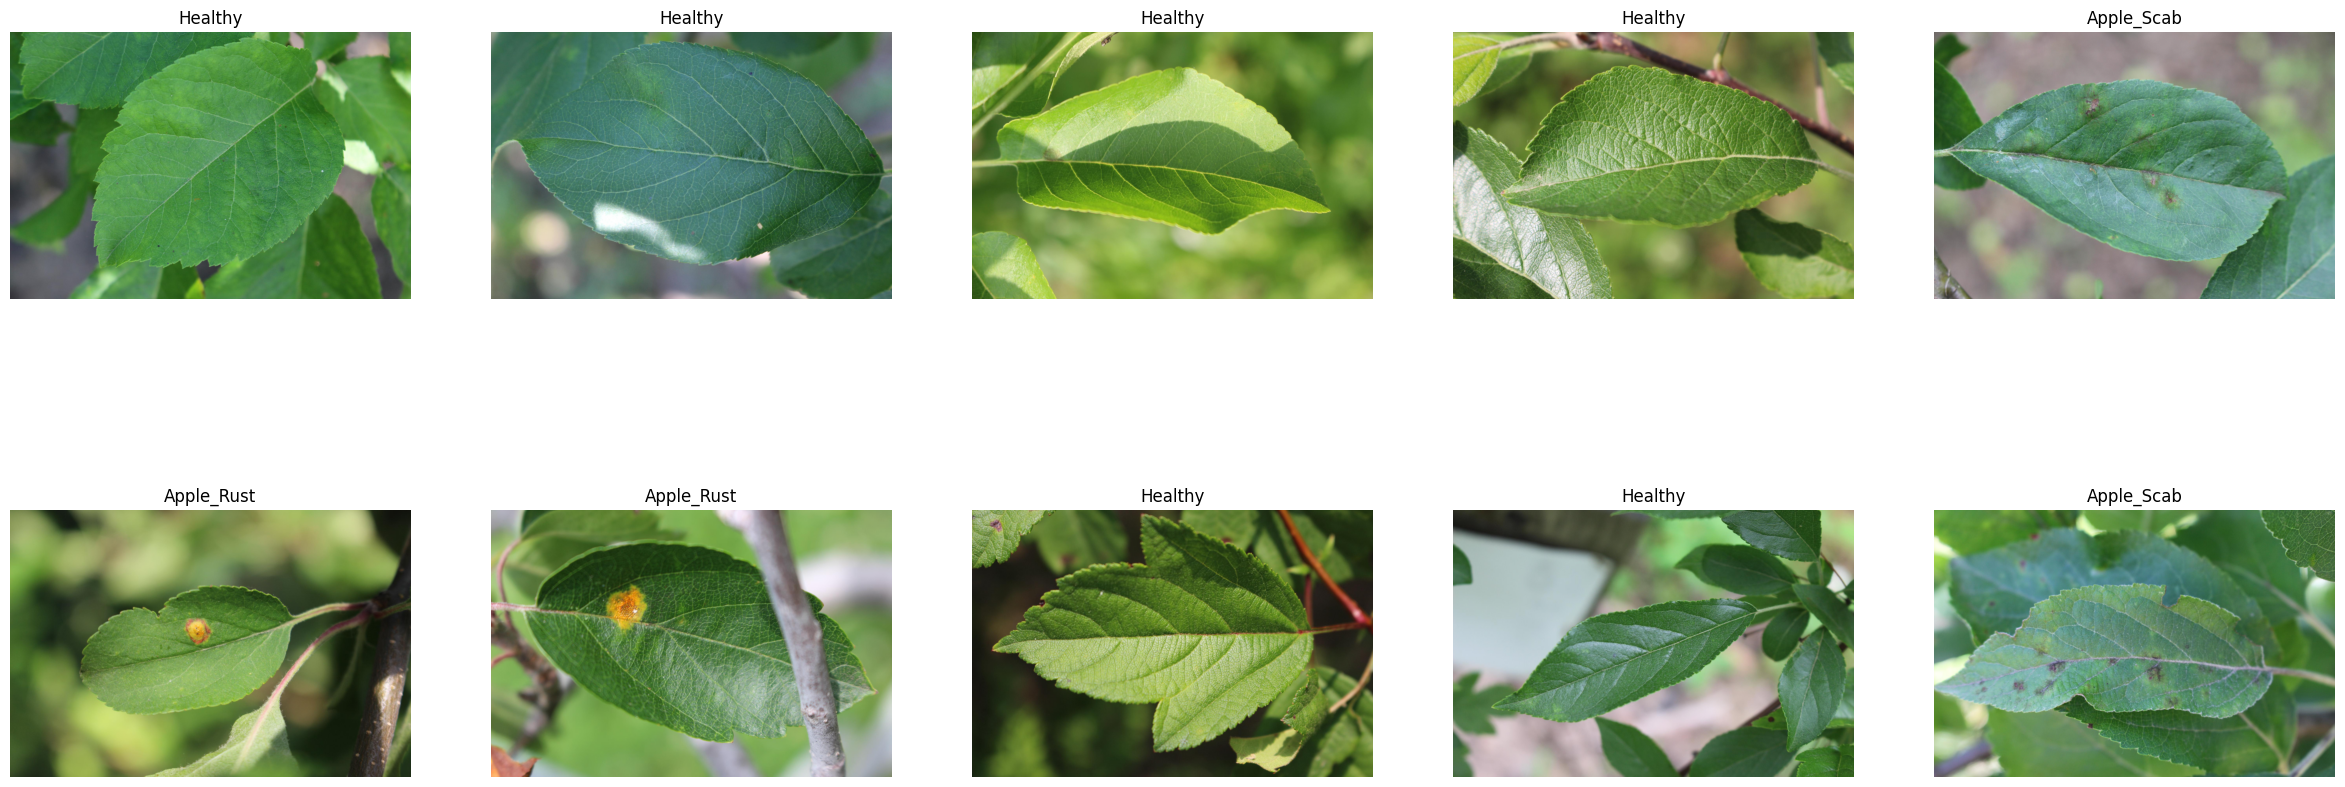

In [ ]:
classes = os.listdir(path_dir+'/train')

plt.figure(figsize=(30,30))
for x in range(10):
  i = random.randint(0,2)
  images = os.listdir(path_dir+'/train'+'/'+classes[i])
  j = random.randint(0,100)
  image = cv2.imread(path_dir+'/train'+'/'+classes[i]+'/'+images[j])
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  ax = plt.subplot(5, 5, x + 1)
  plt.imshow(image)
  plt.title(classes[i])
  plt.axis("off")

plt.show()

In [ ]:
data_generator = ImageDataGenerator(
    rescale=1./255,  # Normalisasi skala gambar
    rotation_range=180,  # Rotasi dalam rentang 180 derajat
    width_shift_range=0.2,  # Pergeseran horisontal sebesar 20% dari lebar gambar
    height_shift_range=0.2,  # Pergeseran vertikal sebesar 20% dari tinggi gambar
    zoom_range=[0.2, 1.8],  # Zoom antara 20% hingga 180%
    shear_range=0.2,  # Rotasi persegi panjang sebesar 20 derajat
    horizontal_flip=True,  # Membalikkan gambar secara horizontal
    vertical_flip=True,  # Membalikkan gambar secara vertikal
    brightness_range=[0.2, 1.8],  # Rentang perubahan kecerahan antara 20% hingga 120%
    fill_mode='nearest'  # Pengisian piksel yang hilang dengan piksel terdekat
)

dataval_generator = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_datagen = data_generator.flow_from_directory(
    path_dir+'/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_datagen = dataval_generator.flow_from_directory(
    path_dir+'/val',
    target_size=(224, 224),
    class_mode='categorical'
)

Found 576 images belonging to 3 classes.
Found 81 images belonging to 3 classes.


#Build Model

In [ ]:
mobilenet = tf.keras.applications.mobilenet.MobileNet(input_shape=(224,224,3),
                                                      include_top=False,
                                                      weights='imagenet')
mobilenet.trainable = False

model = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.25),
    Dense(3, activation="softmax", name="classification")
])

In [ ]:
fname="/content/drive/MyDrive/Coding/Skripsi/Model/Model_B_0,25_256/Model/Model.B5.025.256_RMSprop.hdf5"
checkpoint = ModelCheckpoint(fname, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
log_file = '/content/drive/MyDrive/Coding/Skripsi/Model/Model_B_0,25_256/Training Log/training_log_B5_0,25_256_RMSprop.csv'
csv_logger = CSVLogger(log_file)
callbacks = [checkpoint, csv_logger]

In [ ]:
from tensorflow.keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate=(0.0001)),
              loss='categorical_crossentropy',
              metrics=['accuracy',tf.keras.metrics.AUC()])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functio  (None, 7, 7, 1024)       3228864   
 nal)                                                            
                                                                 
 global_average_pooling2d_1   (None, 1024)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 flatten_1 (Flatten)         (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 256)               262400    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 classification (Dense)      (None, 3)                

In [ ]:
start_time = time.time()
history = model.fit(train_datagen,
                    validation_data=val_datagen,
                    epochs=100,
                    callbacks=callbacks,
                    verbose=1)
end_time = time.time()

Epoch 1/100
18/18 [==============================] - ETA: 0s - loss: 1.2152 - accuracy: 0.4097 - auc_1: 0.5886
Epoch 1: val_accuracy improved from -inf to 0.56790, saving model to /content/drive/MyDrive/Coding/Skripsi/Model/Model_B_0,25_256/Model/Model.B5.025.256_RMSprop.hdf5
18/18 [==============================] - 77s 4s/step - loss: 1.2152 - accuracy: 0.4097 - auc_1: 0.5886 - val_loss: 0.8424 - val_accuracy: 0.5679 - val_auc_1: 0.7841
Epoch 2/100
18/18 [==============================] - ETA: 0s - loss: 0.9272 - accuracy: 0.5694 - auc_1: 0.7539
Epoch 2: val_accuracy improved from 0.56790 to 0.80247, saving model to /content/drive/MyDrive/Coding/Skripsi/Model/Model_B_0,25_256/Model/Model.B5.025.256_RMSprop.hdf5
18/18 [==============================] - 34s 2s/step - loss: 0.9272 - accuracy: 0.5694 - auc_1: 0.7539 - val_loss: 0.6203 - val_accuracy: 0.8025 - val_auc_1: 0.9184
Epoch 3/100
18/18 [==============================] - ETA: 0s - loss: 0.8236 - accuracy: 0.6424 - auc_1: 0.8124
Ep

In [ ]:
training_time = end_time - start_time

m, s = divmod(training_time, 60)
h, m = divmod(m, 60)
training_time_format = "%d:%02d:%02d" % (h, m, s)

print("Waktu Pelatihan: %s" % training_time_format)

Waktu Pelatihan: 1:01:35


#Evaluasi Model

3/3 [==============================] - 3s 790ms/step - loss: 0.1849 - accuracy: 0.9383 - auc_1: 0.9918


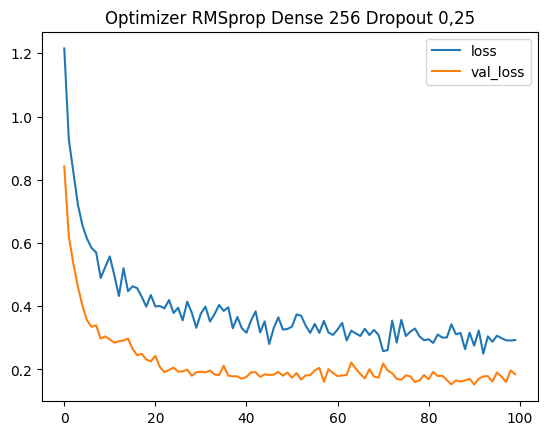

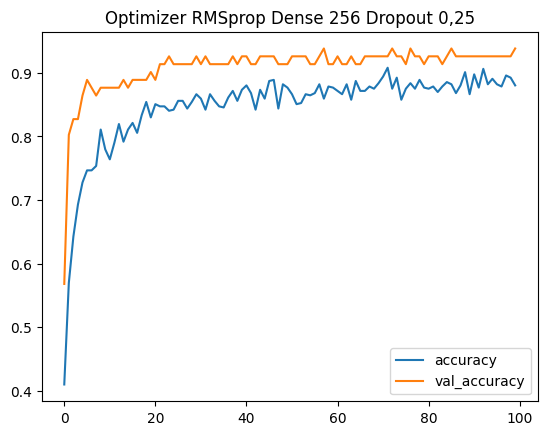

In [ ]:
model.evaluate(val_datagen)

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy','val_accuracy'],loc='best')
plt.title('Optimizer RMSprop Dense 256 Dropout 0,25')
plt.show()

#Testing Model dengan Confusion Matrix

In [ ]:
# Mendefinisikan path ke direktori gambar pengujian
test_dir = "/content/drive/MyDrive/Coding/Skripsi/Dataset/skenario_data_B/test"

# Membuat objek ImageDataGenerator untuk normalisasi data
test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat generator data pengujian
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # Ukuran gambar target
    class_mode='categorical',  # Mode kelas berdasarkan direktori
    shuffle=False  # Jangan mengacak urutan data
)


Found 168 images belonging to 3 classes.


6/6 [==============================] - 71s 14s/step


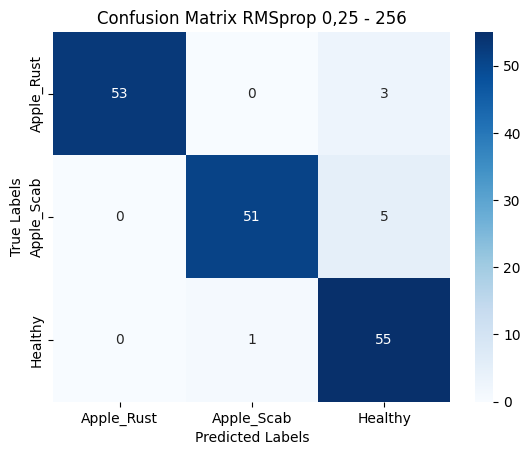

In [ ]:
# Mendapatkan prediksi kelas dari model untuk data pengujian
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Mendapatkan label yang sebenarnya untuk data pengujian
y_true = test_generator.classes

# Menghitung matriks kebingungan
cm = confusion_matrix(y_true, y_pred_classes)

# Mendefinisikan label kelas
class_labels = test_generator.class_indices

# Membuat heatmap dari matriks kebingungan
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Menyesuaikan tampilan plot
plt.title('Confusion Matrix RMSprop 0,25 - 256')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Menampilkan plot
plt.show()
